### 🌳 **Construire un modèle de Machine Learning avec un arbre de décision**

Dans ce notebook, nous allons utiliser un **arbre de décision** pour construire un premier modèle de machine learning en Python.

---

📺 J’ai également réalisé une vidéo pour comprendre le principe et les bases mathématiques des arbres de décision :  
https://youtu.be/ASrCGXMT55I?si=iSs5uQQYq0F86uIc

---

#### **Objectif**

L’objectif est de suivre un petit pipeline complet :
- charger les données,
- les comprendre,
- entraîner un modèle,
- faire des prédictions,
- évaluer ses performances.

#### 💻 **Exécuter ce notebook avec Google Colab**

Si vous n’avez pas Python installé sur votre ordinateur, vous pouvez exécuter ce notebook gratuitement avec **Google Colab**.

#### **Étapes à suivre** :

1. Ouvrir Google Colab : https://colab.research.google.com/

2. Se connecter avec un compte Google

3. Importer le notebook :
   - Cliquer sur **Fichier > Importer un notebook**
   - Puis sélectionner le fichier

4. Exécuter les cellules :
   - Cliquer sur une cellule
   - Puis appuyer sur **Shift + Entrée**
   - Ou utiliser le bouton ▶️


#### 📌 **Plan du notebook**

Dans ce notebook, nous allons suivre les étapes suivantes :

- 📥 Chargement des librairies  
- 📊 Présentation du jeu de données  
- 🏷️ Compréhension de l’en-tête du dataset  
- 🔍 Analyse exploratoire rapide  
- 🎯 Sélection des variables explicatives et de la variable cible  
- ✂️ Division des données en entraînement et test  
- 🌳 Entraînement d’un arbre de décision  
- 🔮 Prédictions sur le jeu de test  
- 📊 Évaluation du modèle  
- ⚙️ Amélioration du modèle  
- ✅ Avantages et limites des arbres de décision

### 📥 **Chargement des librairies**

Nous allons commencer par importer les librairies nécessaires.

- `pandas` permet de manipuler les données sous forme de tableau.
- `DecisionTreeClassifier` permet de construire un modèle d’arbre de décision.
- `train_test_split` permet de séparer les données en deux parties : entraînement et test.
- Les métriques permettent d’évaluer les performances du modèle.

In [1]:
# Import des librairies principales
import pandas as pd
import matplotlib.pyplot as plt

# Import du modèle arbre de décision
from sklearn.tree import DecisionTreeClassifier

# Import de la fonction de division train/test
from sklearn.model_selection import train_test_split

# Import des métriques d'évaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### 📊 **Description du dataset**

Nous allons utiliser le dataset **Pima Indians Diabetes Database**.

🔗 Lien Kaggle du dataset : https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

Ce dataset provient du **National Institute of Diabetes and Digestive and Kidney Diseases**.

🎯 **Objectif :**  
Prédire si une patiente est diabétique ou non à partir de plusieurs mesures médicales.

👩 **Population étudiée :**
- Femmes uniquement
- Âgées d’au moins 21 ans
- D’origine Pima Indian

📈 **Contenu du dataset :**  
Chaque ligne correspond à une patiente. Les colonnes contiennent des informations médicales comme le taux de glucose, l’âge, l’indice de masse corporelle, etc.

🎯 **Variable cible :**
- `label = 1` : patiente diabétique
- `label = 0` : patiente non diabétique

### 📊 **Chargement des données**

Pour que tout le monde puisse exécuter le notebook sans télécharger de fichier, nous allons charger les données directement depuis une URL.

Nous allons d’abord charger le dataset de manière simple, puis observer un petit problème lié aux noms des colonnes.

In [4]:
# URL du dataset au format CSV
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Premier chargement naïf du dataset
pima = pd.read_csv(url)

# Affichage des premières lignes
pima.head()

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


#### 🏷️ **Problème avec l’en-tête du dataset**

Ici, on remarque que les noms des colonnes ne sont pas explicites.

En fait, le fichier brut ne contient pas de ligne d’en-tête (*header*) avec les noms des colonnes.

Quand on écrit simplement `pd.read_csv(url)`, pandas suppose automatiquement que la première ligne du fichier contient les noms des colonnes.  
Résultat : la première observation du dataset est utilisée comme en-tête, ce qui n’est pas correct.

Pour corriger cela, nous devons préciser à pandas que le fichier n’a pas d’en-tête avec :

`header=None`

In [3]:
# Chargement du dataset en indiquant qu'il n'y a pas d'en-tête
pima = pd.read_csv(url, header=None)

# Affichage des premières lignes
pima.head()

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 🏷️ **Ajout des noms de colonnes**

Maintenant, les colonnes sont bien affichées, mais elles sont nommées automatiquement avec des indices : `0`, `1`, `2`, etc.

Ce n’est pas très lisible pour l’analyse.

Nous allons donc ajouter des noms de colonnes plus explicites.

In [5]:
# Définition des noms de colonnes
col_names = [
    'pregnant',   # Nombre de grossesses
    'glucose',    # Taux de glucose
    'bp',         # Pression artérielle
    'skin',       # Épaisseur du pli cutané
    'insulin',    # Niveau d'insuline
    'bmi',        # Indice de masse corporelle
    'pedigree',   # Fonction liée aux antécédents familiaux
    'age',        # Âge
    'label'       # Variable cible : 1 = diabétique, 0 = non diabétique
]

# Chargement du dataset avec les noms de colonnes
pima = pd.read_csv(url, header=None, names=col_names)

# Affichage des premières lignes
pima.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#### 🔍 **Analyse exploratoire rapide avec `ydata-profiling`**

Avant de construire le modèle, on peut faire une première analyse exploratoire des données.

Pour cela, nous allons utiliser la bibliothèque `ydata-profiling`.

Elle permet de générer automatiquement un rapport contenant :

- des statistiques descriptives,
- les valeurs manquantes,
- les distributions des variables,
- les corrélations,
- et d’autres informations utiles sur le dataset.

In [ ]:
# Installation de la bibliothèque ydata-profiling
!pip install ydata-profiling

In [ ]:
# Import de la bibliothèque après installation
from ydata_profiling import ProfileReport

# Génération du rapport de profilage
profile = ProfileReport(pima, title="Profiling Report")

# Sauvegarde du rapport dans un fichier HTML
profile.to_file("pima_profiling.html")

Après l’exécution de cette cellule, un fichier nommé **`pima_profiling.html`** sera sauvegardé.

Vous pourrez l’ouvrir pour consulter le rapport complet d’analyse exploratoire.

#### 🎯 **Sélection des variables**

Nous allons maintenant séparer le dataset en deux parties :

- **X** : les variables explicatives (*features*)  
- **y** : la variable cible (*target*)

Les variables explicatives sont les informations que le modèle va utiliser pour apprendre.

La variable cible est ce que le modèle doit prédire.

Ici, nous voulons prédire la colonne `label`, c’est-à-dire si une patiente est diabétique ou non.

In [9]:
# Sélection des variables explicatives
feature_cols = ['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree']

# X contient les variables explicatives
X = pima[feature_cols]

# y contient la variable cible
y = pima['label']

#### ✂️ **Division des données : entraînement et test**

Pour évaluer correctement notre modèle, nous devons le tester sur des données qu’il n’a jamais vues.

Nous allons donc diviser le dataset en deux parties :

- **70% des données** pour entraîner le modèle
- **30% des données** pour tester le modèle

Cela permet de vérifier si le modèle généralise bien sur de nouvelles données.

In [10]:
# Division des données en train/test
# test_size=0.3 signifie que 30% des données seront utilisées pour le test
# donc 70% seront utilisées pour l'entraînement
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=1
)

#### 🌳 **Entraînement du premier modèle**

Nous allons maintenant créer un premier modèle d’arbre de décision.

Un arbre de décision fonctionne comme une suite de questions.  
À chaque étape, le modèle choisit une variable et une condition pour séparer les données.

In [21]:
# Création du modèle d'arbre de décision
clf = DecisionTreeClassifier()

# Entraînement du modèle sur les données d'entraînement
clf.fit(X_train, y_train)

DecisionTreeClassifier()

#### 🔮 **Prédictions sur le jeu de test**

Une fois le modèle entraîné, nous allons l’utiliser pour faire des prédictions sur le jeu de test.

Le jeu de test contient des données que le modèle n’a pas vues pendant l’entraînement.

In [22]:
# Prédictions sur le jeu de test
y_pred = clf.predict(X_test)

#### 📊 **Évaluation du premier modèle**

Nous allons évaluer le modèle avec plusieurs métriques :

- **Exactitude (Accuracy)** : proportion totale de bonnes prédictions
- **Précision (Precision)** : parmi les cas prédits positifs, combien sont réellement positifs
- **Rappel (Recall)** : capacité du modèle à détecter les vrais cas positifs
- **Matrice de confusion** : détail des bonnes et mauvaises prédictions

Dans un contexte médical, le **rappel** est particulièrement important, car on veut éviter de manquer des personnes réellement malades.

📚 Voici également un lien que vous pouvez consulter pour mieux comprendre les formules de calcul et la matrice de confusion :  
https://www.datacamp.com/fr/tutorial/what-is-a-confusion-matrix-in-machine-learning

In [23]:
# Calcul des métriques du premier modèle
exactitude = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
rappel = recall_score(y_test, y_pred)

# Affichage des résultats
print("Exactitude :", exactitude)
print("Précision :", precision)
print("Rappel :", rappel)

Exactitude : 0.7056277056277056
Précision : 0.6133333333333333
Rappel : 0.5411764705882353


#### 📊 **Matrice de confusion**

La matrice de confusion permet de mieux comprendre les erreurs du modèle.

Elle compare les vraies valeurs avec les prédictions du modèle.

On distingue :

- **Vrais négatifs (TN)** : non diabétiques correctement prédits
- **Faux positifs (FP)** : non diabétiques prédits comme diabétiques
- **Faux négatifs (FN)** : diabétiques prédits comme non diabétiques
- **Vrais positifs (TP)** : diabétiques correctement prédits

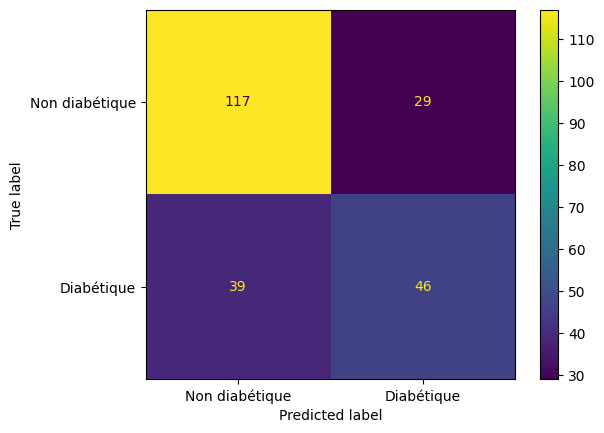

In [24]:
# Création de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Affichage de la matrice de confusion
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non diabétique", "Diabétique"]
)

disp.plot()
plt.show()

#### 🌳 **Visualisation du premier arbre**

Nous pouvons visualiser l’arbre de décision pour comprendre comment le modèle prend ses décisions.

Chaque nœud de l’arbre correspond à une condition sur une variable.

In [ ]:
# Installation des bibliothèques nécessaires pour la visualisation
!pip install graphviz
!pip install pydotplus

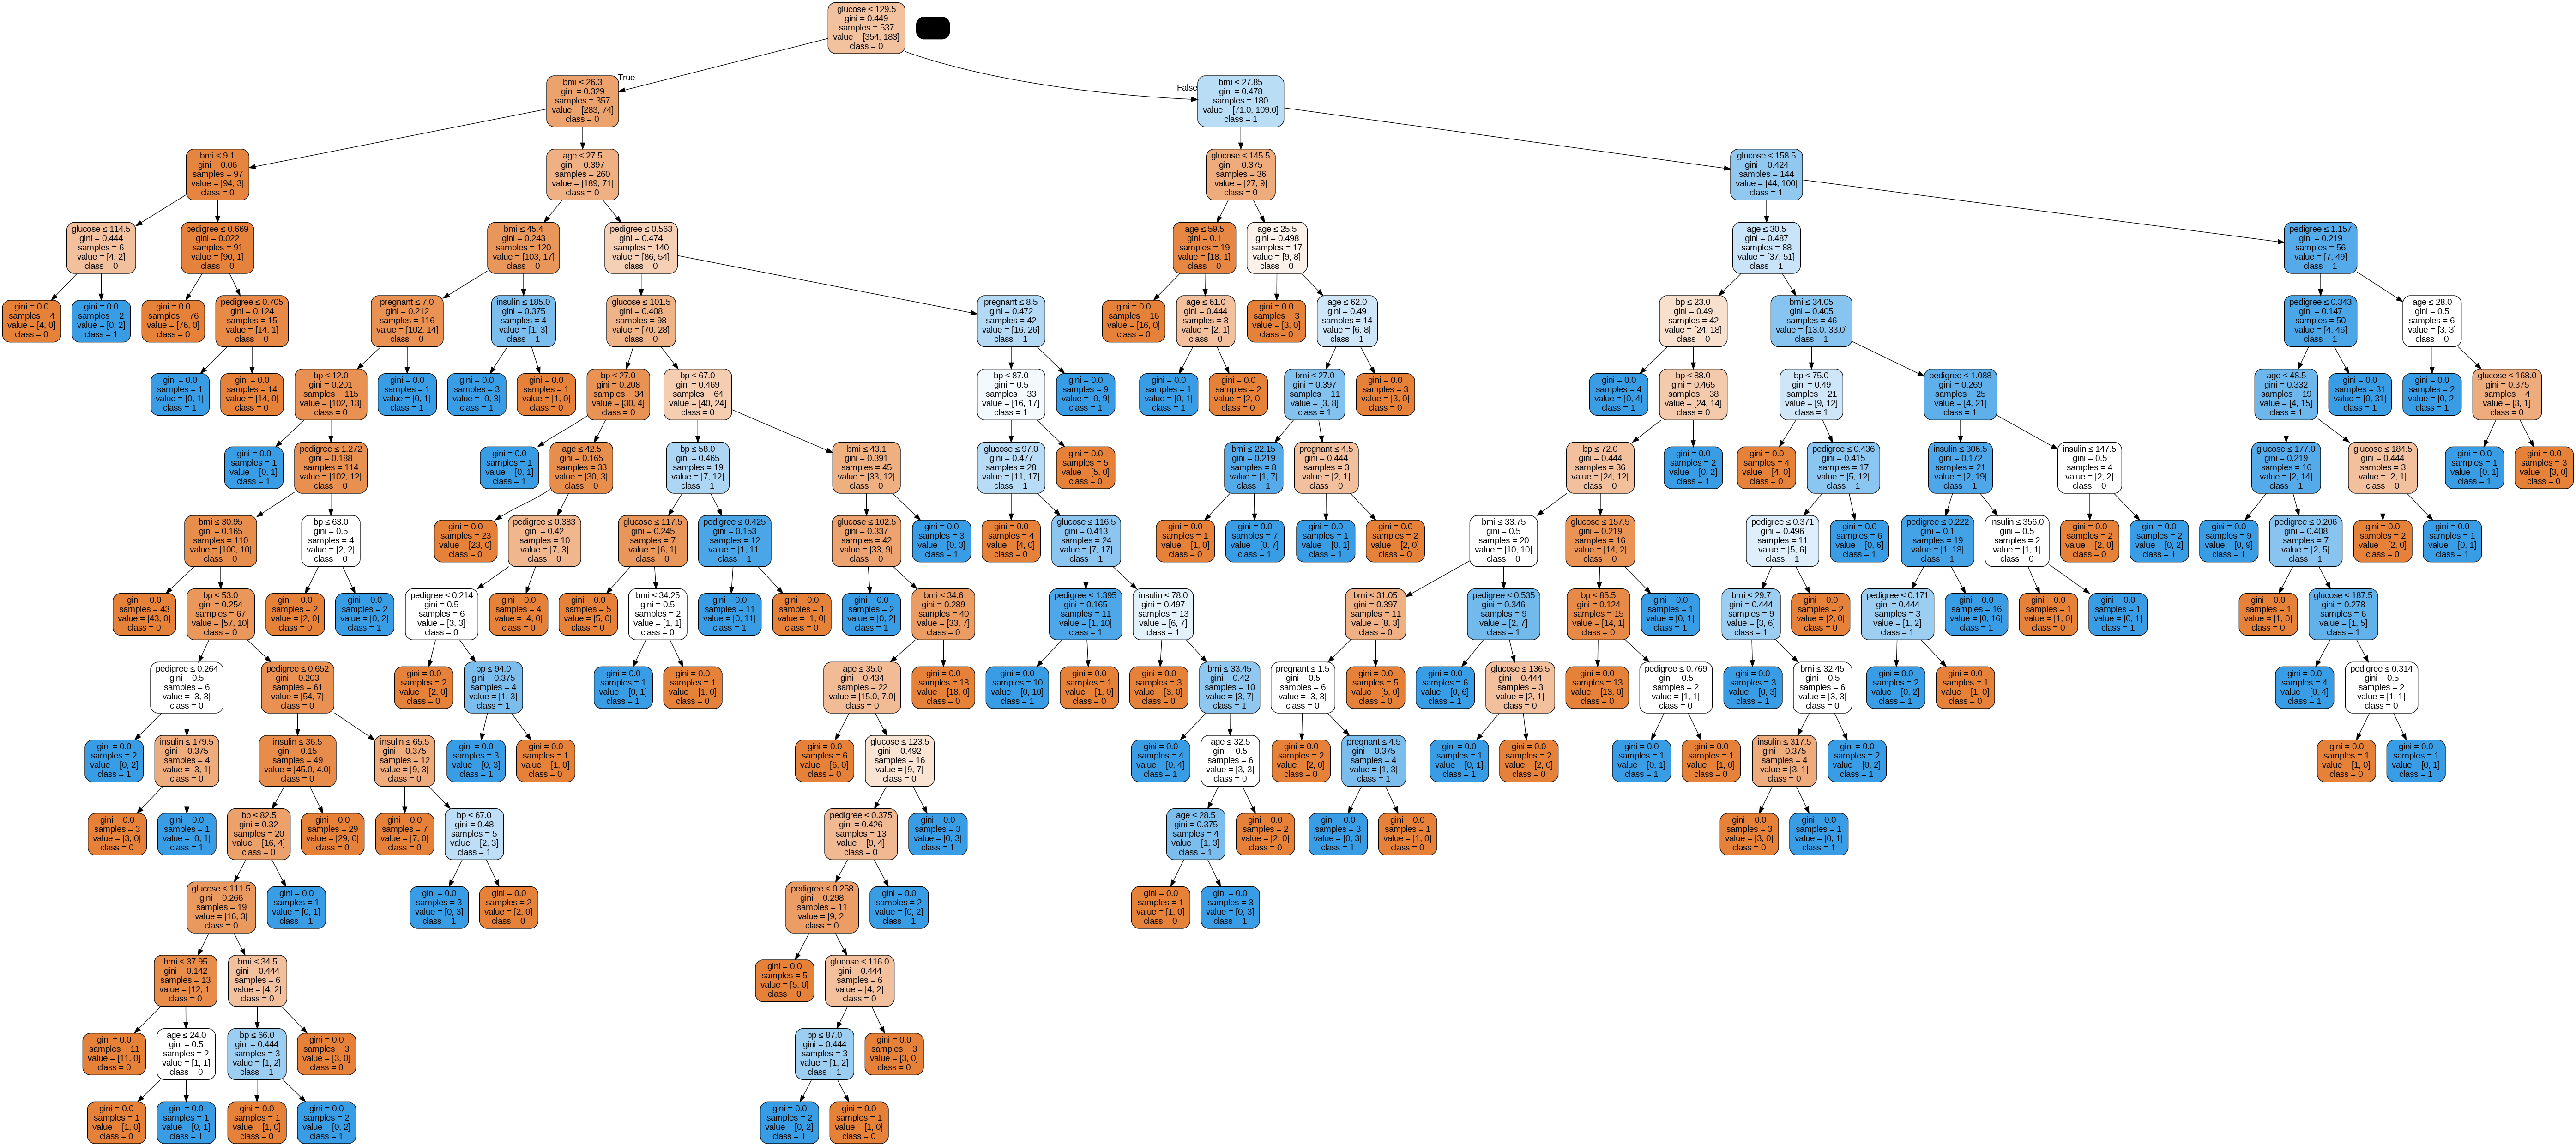

In [25]:
# Import des outils de visualisation
from sklearn.tree import export_graphviz
from io import StringIO
from IPython.display import Image
import pydotplus

# Création d'un objet texte qui va contenir la structure de l'arbre
dot_data = StringIO()

# Export de l'arbre au format graphviz
export_graphviz(
    clf,
    out_file=dot_data,
    filled=True,
    rounded=True,
    special_characters=True,
    feature_names=feature_cols,
    class_names=['0', '1']
)

# Création du graphe
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

# Affichage de l'arbre
Image(graph.create_png())

#### ⚙️ **Amélioration du modèle**

Le premier arbre peut devenir trop complexe.

Un arbre trop profond peut apprendre trop fortement les données d’entraînement : c’est ce qu’on appelle le **sur-apprentissage** (*overfitting*).

Nous allons maintenant ajuster certains paramètres :

- `criterion="entropy"` : utilise le gain d’information pour choisir les séparations
- `max_depth=3` : limite la profondeur maximale de l’arbre

L’objectif est d’obtenir un modèle plus simple, plus lisible et potentiellement plus performant.

In [26]:
# Création d'un modèle optimisé
clf_optimized = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3
)

# Entraînement du modèle optimisé
clf_optimized.fit(X_train, y_train)

# Prédictions avec le modèle optimisé
y_pred_optimized = clf_optimized.predict(X_test)

#### 📊 **Évaluation du modèle optimisé**

Nous évaluons maintenant le modèle optimisé avec les mêmes métriques que précédemment.

Cela permet de comparer les performances avant et après l’ajustement des paramètres.

In [27]:
# Calcul des métriques du modèle optimisé
exactitude_opt = accuracy_score(y_test, y_pred_optimized)
precision_opt = precision_score(y_test, y_pred_optimized)
rappel_opt = recall_score(y_test, y_pred_optimized)

# Affichage des résultats
print("Exactitude :", exactitude_opt)
print("Précision :", precision_opt)
print("Rappel :", rappel_opt)

Exactitude : 0.7705627705627706
Précision : 0.7105263157894737
Rappel : 0.6352941176470588


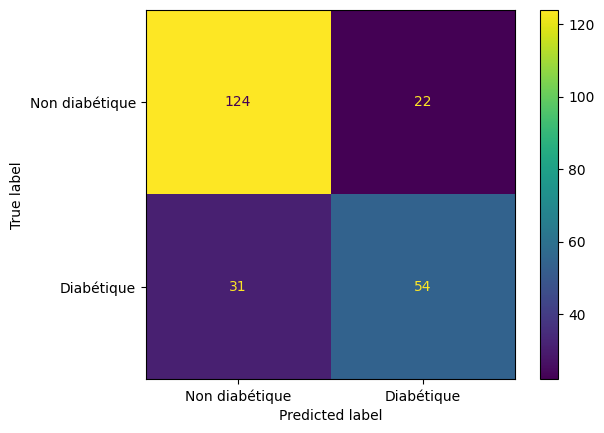

In [28]:
# Matrice de confusion du modèle optimisé
cm_opt = confusion_matrix(y_test, y_pred_optimized)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_opt,
    display_labels=["Non diabétique", "Diabétique"]
)

disp.plot()
plt.show()

#### 🌳 **Visualisation du modèle optimisé**

Nous visualisons maintenant l’arbre optimisé.

Comme sa profondeur est limitée à 3, il est normalement plus simple à lire que le premier arbre.

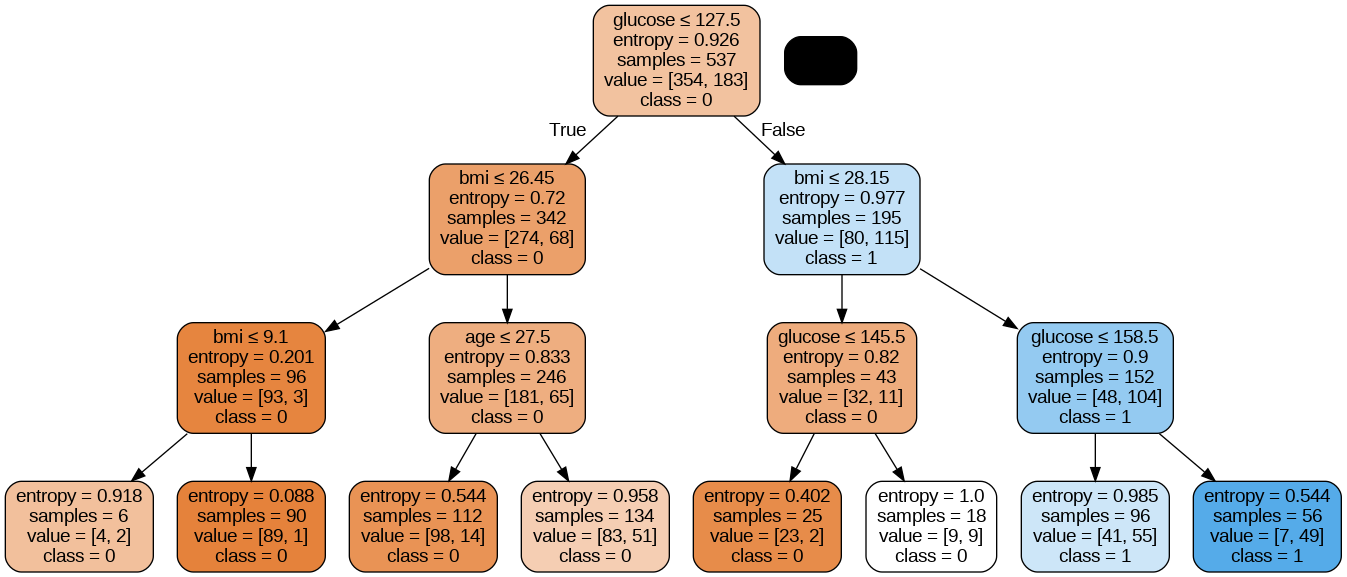

In [29]:
# Création d'un objet texte pour stocker l'arbre optimisé
dot_data = StringIO()

# Export du modèle optimisé au format graphviz
export_graphviz(
    clf_optimized,
    out_file=dot_data,
    filled=True,
    rounded=True,
    special_characters=True,
    feature_names=feature_cols,
    class_names=['0', '1']
)

# Création du graphe
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

# Affichage de l'arbre optimisé
Image(graph.create_png())

### ✅ **Avantages et limites des arbres de décision**

#### Avantages

- Faciles à comprendre et à visualiser
- Peu de prétraitement nécessaire
- Capables de capturer des relations non linéaires
- Pas besoin de faire d’hypothèse forte sur la distribution des données

#### Limites

- Sensibles au bruit
- Risque de sur-apprentissage
- Peuvent être instables : un petit changement dans les données peut produire un arbre différent
- Peuvent être moins performants si les classes sont très déséquilibrées

Ces limites peuvent être réduites avec des méthodes d’ensemble, comme le **bagging** ou le **boosting**.

## 🎯 **Conclusion**

Dans ce notebook, nous avons construit un premier modèle de machine learning avec un arbre de décision.

Nous avons vu comment :

- charger un dataset,
- comprendre sa structure,
- ajouter des noms de colonnes,
- séparer les variables explicatives et la variable cible,
- diviser les données en entraînement et test,
- entraîner un arbre de décision,
- évaluer ses performances,
- améliorer le modèle avec quelques paramètres.

L’arbre de décision est un excellent premier modèle pour comprendre les bases du machine learning, car il est simple, visuel et interprétable.

---

### 🌐 **Mes réseaux sociaux**

- LinkedIn : https://www.linkedin.com/in/clémence-audrey-emaha-tchendjam
- Facebook : https://www.facebook.com/clemence.emaha/
- YouTube  : https://www.youtube.com/@Clemence-Emaha